# Notebook Overview

This notebook was originally designed for **multi-node experiments**. For users who do not have a multi-node environment or want quick visualization, we provide a **single-machine, multi-process** version.

The core logic is identical to the multi-node implementation, except for process launching.

---

## Communication

Thanks to our custom communication framework:

- Multi-process workers communicate over **TCP loopback (127.0.0.1)**  
- The same networking stack is used as in the multi-node version  

This makes the notebook a faithful stand-in for real distributed runs.

---

## Multi-Node Version

For multi-node experiments, use the scripts in:

```text
examples/multi_node
```

# 1. Basic parameters

In [ ]:
import multiprocessing as mp
import numpy as np
import numpy.typing as npt

if __name__ == "__main__":
    import pathlib

    N_STATE = 20
    N_ITER = 200
    ALPHA = 0.3
    EXP_NAME = "random"
    ROOT_PATH = pathlib.Path.cwd().parent.parent
    FIGURE_PATH = ROOT_PATH / "figures" / "small_scale" / EXP_NAME
    FIGURE_PATH.mkdir(parents=True, exist_ok=True)

# 2. Define the graph topology

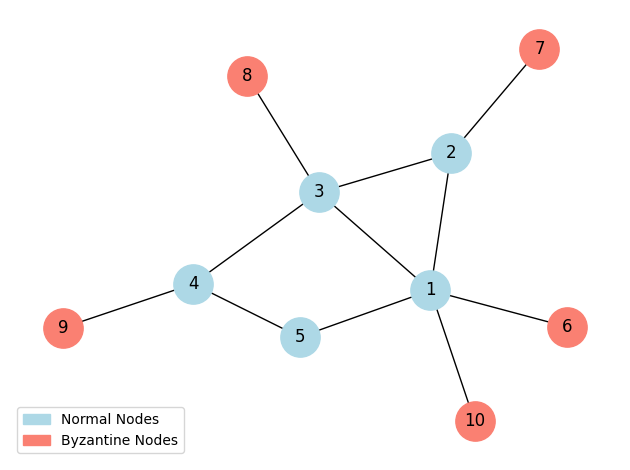

In [89]:
def graph(nodes: list[str], edges: list[tuple[str, str]]) -> None:
    from logging import basicConfig, INFO

    basicConfig(level=INFO)

    from topolink import Graph

    graph = Graph(nodes, edges)

    graph.deploy()


if __name__ == "__main__":
    NORMAL_NODES = ["1", "2", "3", "4", "5"]
    NORMAL_EDGES = [
        ("1", "2"),
        ("2", "3"),
        ("3", "4"),
        ("4", "5"),
        ("5", "1"),
        ("1", "3"),
    ]
    BYZANTINE_NODES = ["6", "7", "8", "9", "10"]
    BYZANTINE_EDGES = [("1", "6"), ("2", "7"), ("3", "8"), ("4", "9"), ("1", "10")]

    NODES = NORMAL_NODES + BYZANTINE_NODES
    EDGES = NORMAL_EDGES + BYZANTINE_EDGES

    N_NORMAL = len(NORMAL_NODES)
    N_BYZANTINE = len(BYZANTINE_NODES)
    N_NODES = N_NORMAL + N_BYZANTINE

    import matplotlib.pyplot as plt
    import networkx as nx

    fig, ax = plt.subplots()

    G = nx.Graph()
    G.add_nodes_from(NODES)
    G.add_edges_from(EDGES)

    pos = nx.spring_layout(G, seed=11, k=0.8)

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=NORMAL_NODES,
        node_color="lightblue",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=BYZANTINE_NODES,
        node_color="salmon",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_edges(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)

    import matplotlib.patches as mpatches

    blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
    red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

    ax.legend(handles=[blue_patch, red_patch], loc="lower left")
    ax.axis("off")
    plt.tight_layout()

    fig.savefig(FIGURE_PATH / "network_topology.pdf", format="pdf")

# 3. Attacker model

In [90]:
def byzantine_node(
    name: str, n_state: int, alpha: float, n_iter: int, exp_name: str
) -> None:
    from numpy.random import seed, uniform
    from topolink import NodeHandle

    nh = NodeHandle(name)

    seed(int(name))  # Ensure reproducibility for each node

    for _ in range(n_iter - 1):
        attack_value = uniform(-100, 100, n_state)
        _ = nh.laplacian(attack_value)

# 4. Standard consensus
## (1) Run the algorithm

In [91]:
def baseline_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        x[k + 1] = x[k] - nh.laplacian(x[k]) * alpha

    return x


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        baseline_results = {
            i: pool.apply_async(baseline_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(
                byzantine_node, args=(i, N_STATE, ALPHA, N_ITER, EXP_NAME)
            )
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        baseline_data = {i: result.get() for i, result in baseline_results.items()}
        byzantine_data = {i: result.get() for i, result in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 192.168.1.102:46443
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '6' joined graph 'default' from 192.168.1.102:45195.
INFO:topolink.graph:Node '4' joined graph 'default' from 192.168.1.102:45087.
INFO:topolink.graph:Node '1' joined graph 'default' from 192.168.1.102:45977.
INFO:topolink.graph:Node '10' joined graph 'default' from 192.168.1.102:46615.
INFO:topolink.graph:Node '9' joined graph 'default' from 192.168.1.102:45661.
INFO:topolink.graph:Node '8' joined graph 'default' from 192.168.1.102:45293.
INFO:topolink.graph:Node '3' joined graph 'default' from 192.168.1.102:44781.
INFO:topolink.graph:Node '2' joined graph 'default' from 192.168.1.102:45129.
INFO:topolink.graph:Node '7' joined graph 'default' from 192.168.1.102:46045.
INFO:topolink.graph:Node '5' joined graph 'default' from 192.168.1.102:46245.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.graph:Sen

## 

## (2) Visualize the Results

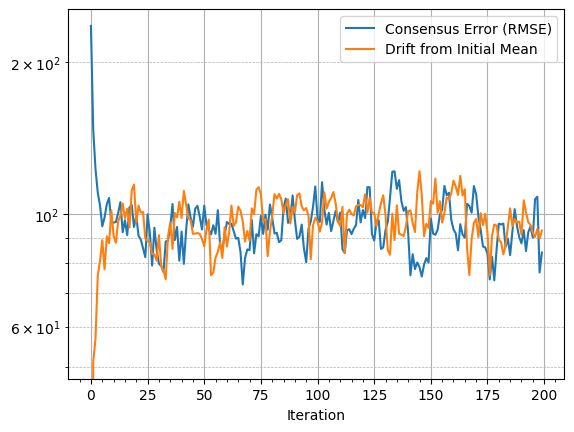

In [92]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots()

    bl_states = np.array([baseline_data[i] for i in NORMAL_NODES])
    avg_states: npt.NDArray[np.float64] = np.average(bl_states, axis=0)
    diffs = bl_states - avg_states
    bl_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

    x0_mean = avg_states[0]
    bl_drift = np.linalg.norm(avg_states - x0_mean[None, :], axis=1)

    ax.semilogy(bl_rmse, label="Consensus Error (RMSE)")
    ax.semilogy(bl_drift, label="Drift from Initial Mean")

    ax.set_xlabel("Iteration")
    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", linewidth=0.8)
    ax.grid(which="minor", axis="y", linestyle="--", linewidth=0.5)
    ax.legend()

# 5. ARepC
## (1) Run the algorithm

In [93]:
def arepc_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    from arepc import ARepC

    agent = ARepC(nh, alpha, eta=0.02, loss_func="qmed", normalization="1.5-entmax")

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    reps = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbors}

    for k in range(n_iter - 1):
        # Compute new state
        x[k + 1] = agent.weighted_mix(x[k])

        # Record normalized weights history
        r = agent.reputations
        for j in nh.neighbors:
            reps[j][k] = r[j]

    return x, reps


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        arepc_results = {
            i: pool.apply_async(arepc_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(
                byzantine_node, args=(i, N_STATE, ALPHA, N_ITER, EXP_NAME)
            )
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        arepc_data = {i: node.get() for i, node in arepc_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 192.168.1.102:45009
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '7' joined graph 'default' from 192.168.1.102:46217.
INFO:topolink.graph:Node '10' joined graph 'default' from 192.168.1.102:45457.
INFO:topolink.graph:Node '2' joined graph 'default' from 192.168.1.102:46035.
INFO:topolink.graph:Node '6' joined graph 'default' from 192.168.1.102:45363.
INFO:topolink.graph:Node '5' joined graph 'default' from 192.168.1.102:45833.
INFO:topolink.graph:Node '4' joined graph 'default' from 192.168.1.102:45075.
INFO:topolink.graph:Node '1' joined graph 'default' from 192.168.1.102:45419.
INFO:topolink.graph:Node '9' joined graph 'default' from 192.168.1.102:45491.
INFO:topolink.graph:Node '3' joined graph 'default' from 192.168.1.102:45811.
INFO:topolink.graph:Node '8' joined graph 'default' from 192.168.1.102:46367.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.graph:Sen

## (2) Visualize the Results
### I. State

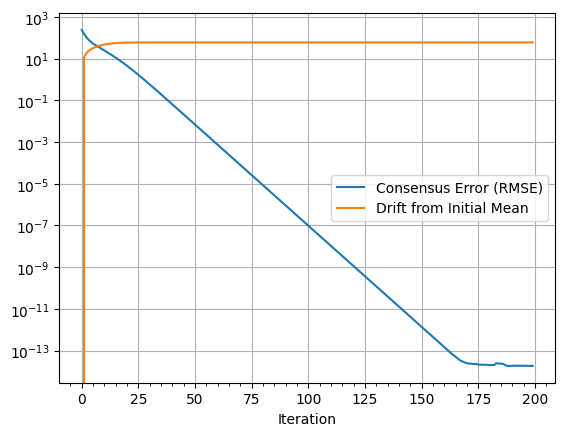

In [94]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots()

    arepc_states = np.array([arepc_data[i][0] for i in NORMAL_NODES])
    avg_states: npt.NDArray[np.float64] = np.average(arepc_states, axis=0)
    diffs = arepc_states - avg_states
    aprec_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

    x0_mean = avg_states[0]
    aprec_drift = np.linalg.norm(avg_states - x0_mean[None, :], axis=1)

    ax.semilogy(aprec_rmse, label="Consensus Error (RMSE)")
    ax.semilogy(aprec_drift, label="Drift from Initial Mean")

    ax.set_xlabel("Iteration")
    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", linewidth=0.8)
    ax.grid(which="minor", axis="y", linestyle="--", linewidth=0.5)
    ax.legend()

### II. Reputation

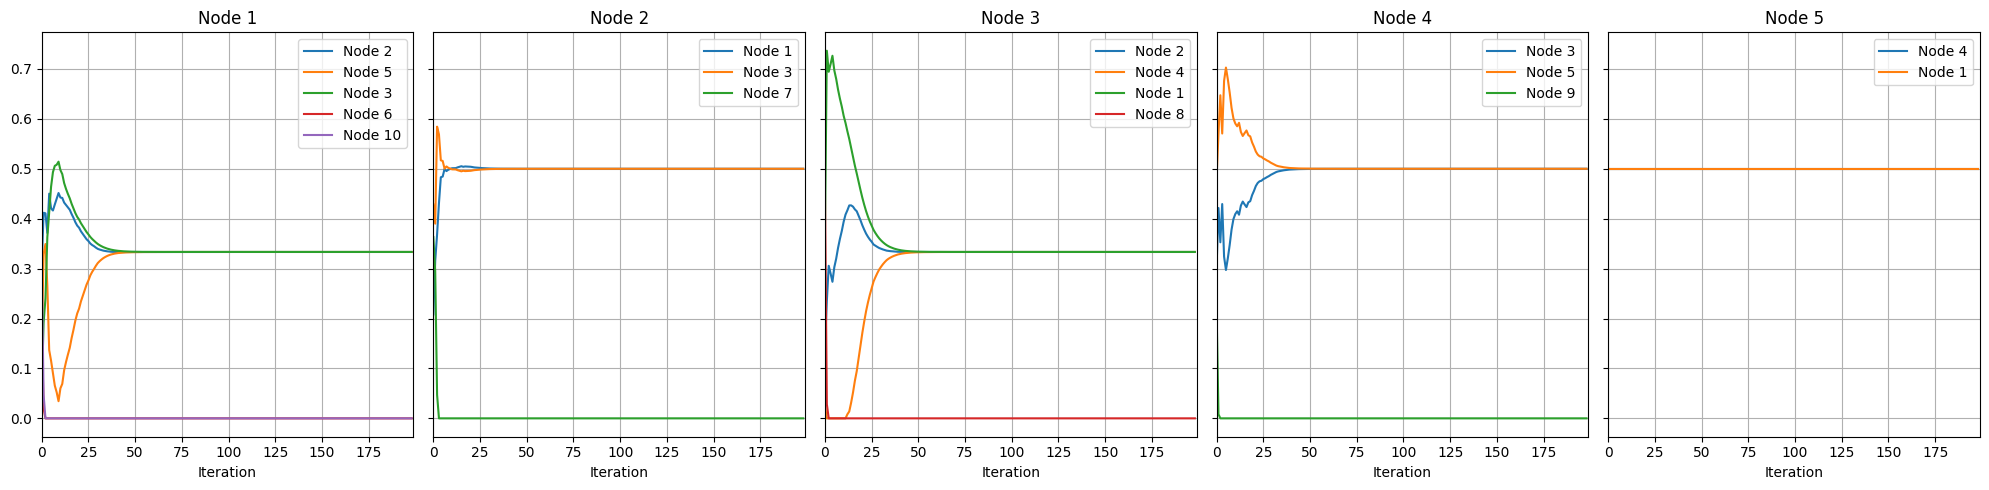

In [95]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.axes as maxes

    axes: tp.Sequence[maxes.Axes]
    fig, axes = plt.subplots(1, N_NORMAL, figsize=(20, 5), sharey=True)

    arepc_probs = {i: arepc_data[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, axes):
        probs_for_i = arepc_probs[i]
        for j in probs_for_i:
            ax.plot(probs_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    fig.tight_layout()

    fig.savefig(FIGURE_PATH / "arepc_reputations.pdf", format="pdf")

# 6. RepC
## (1) Run the algorithm

In [96]:
def repc_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from topolink import NodeHandle

    nh = NodeHandle(name)

    from arepc.baselines import RepC

    agent = RepC(nh, alpha, f=1)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    reps = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbors}

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

        # Record normalized weights history
        r = agent.reputations
        for j in nh.neighbors:
            reps[j][k] = r[j]

    return states, reps


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        repc_results = {
            i: pool.apply_async(repc_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(
                byzantine_node, args=(i, N_STATE, ALPHA, N_ITER, EXP_NAME)
            )
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        repc_data = {i: node.get() for i, node in repc_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 192.168.1.102:44677
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '10' joined graph 'default' from 192.168.1.102:45157.
INFO:topolink.graph:Node '9' joined graph 'default' from 192.168.1.102:46551.
INFO:topolink.graph:Node '3' joined graph 'default' from 192.168.1.102:45219.
INFO:topolink.graph:Node '5' joined graph 'default' from 192.168.1.102:44807.
INFO:topolink.graph:Node '7' joined graph 'default' from 192.168.1.102:45257.
INFO:topolink.graph:Node '6' joined graph 'default' from 192.168.1.102:46469.
INFO:topolink.graph:Node '4' joined graph 'default' from 192.168.1.102:44909.
INFO:topolink.graph:Node '8' joined graph 'default' from 192.168.1.102:45135.
INFO:topolink.graph:Node '1' joined graph 'default' from 192.168.1.102:45689.
INFO:topolink.graph:Node '2' joined graph 'default' from 192.168.1.102:44697.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.graph:Sen

## (2) Visualize the Results
### I. State

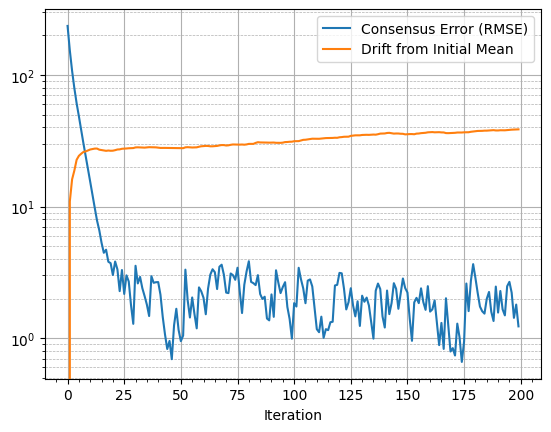

In [97]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots()

    repc_states = np.array([repc_data[i][0] for i in NORMAL_NODES])
    avg_states: npt.NDArray[np.float64] = np.average(repc_states, axis=0)
    diffs = repc_states - avg_states
    repc_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

    x0_mean = avg_states[0]
    repc_drift = np.linalg.norm(avg_states - x0_mean[None, :], axis=1)

    ax.semilogy(repc_rmse, label="Consensus Error (RMSE)")
    ax.semilogy(repc_drift, label="Drift from Initial Mean")

    ax.set_xlabel("Iteration")
    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", linewidth=0.8)
    ax.grid(which="minor", axis="y", linestyle="--", linewidth=0.5)
    ax.legend()

### II. Reputation

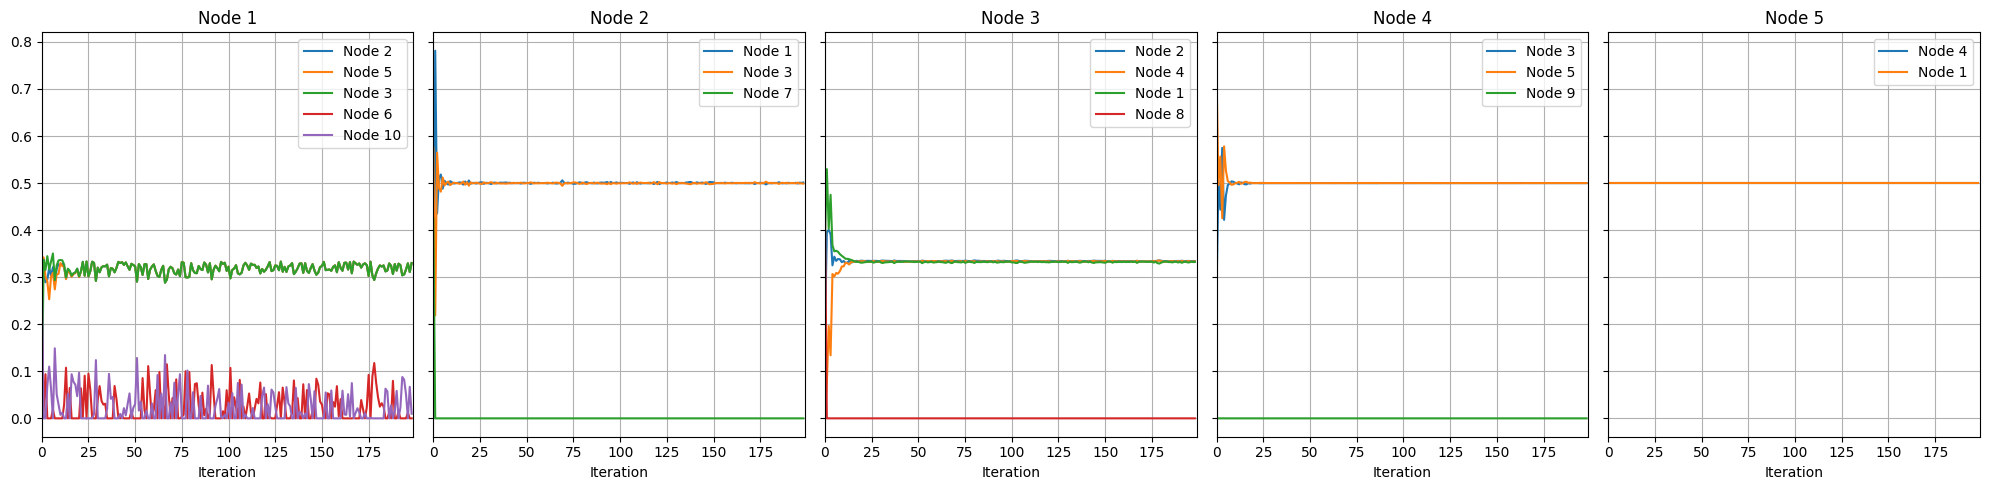

In [98]:
if __name__ == "__main__":
    axes: tp.Sequence[maxes.Axes]
    fig, axes = plt.subplots(1, N_NORMAL, figsize=(20, 5), sharey=True)

    repc_reps = {i: repc_data[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, axes):
        reps_for_i = repc_reps[i]
        for j in reps_for_i:
            ax.plot(reps_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    fig.tight_layout()

    fig.savefig(FIGURE_PATH / "repc_reputations.pdf", format="pdf")

# 7. W-MSR
## (1) Run the algorithm

In [99]:
def wmsr_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from topolink import NodeHandle

    nh = NodeHandle(name)

    from arepc.baselines import WMSR

    agent = WMSR(nh, alpha, f=1)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

    return states


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        wmsr_results = {
            i: pool.apply_async(wmsr_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(
                byzantine_node, args=(i, N_STATE, ALPHA, N_ITER, EXP_NAME)
            )
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        wmsr_data = {i: node.get() for i, node in wmsr_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 192.168.1.102:45201
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '4' joined graph 'default' from 192.168.1.102:45611.
INFO:topolink.graph:Node '10' joined graph 'default' from 192.168.1.102:44803.
INFO:topolink.graph:Node '9' joined graph 'default' from 192.168.1.102:46189.
INFO:topolink.graph:Node '6' joined graph 'default' from 192.168.1.102:45837.
INFO:topolink.graph:Node '7' joined graph 'default' from 192.168.1.102:44761.
INFO:topolink.graph:Node '1' joined graph 'default' from 192.168.1.102:44795.
INFO:topolink.graph:Node '3' joined graph 'default' from 192.168.1.102:45191.
INFO:topolink.graph:Node '2' joined graph 'default' from 192.168.1.102:46023.
INFO:topolink.graph:Node '8' joined graph 'default' from 192.168.1.102:46259.
INFO:topolink.graph:Node '5' joined graph 'default' from 192.168.1.102:44765.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.graph:Sen

## (2) Visualize the Results

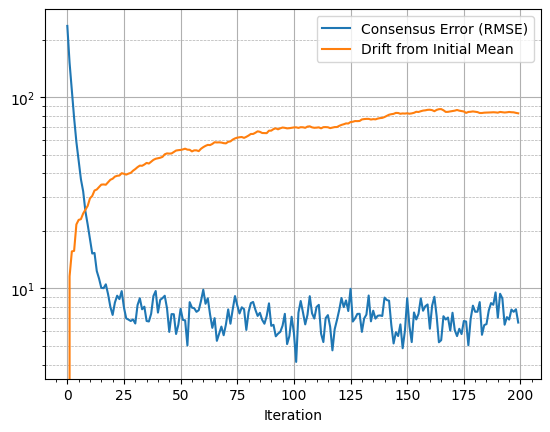

In [100]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots()

    wmsr_states = np.array([wmsr_data[i] for i in NORMAL_NODES])
    avg_states: npt.NDArray[np.float64] = np.average(wmsr_states, axis=0)
    diffs = wmsr_states - avg_states
    wmsr_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

    x0_mean = avg_states[0]
    wmsr_drift = np.linalg.norm(avg_states - x0_mean[None, :], axis=1)

    ax.semilogy(wmsr_rmse, label="Consensus Error (RMSE)")
    ax.semilogy(wmsr_drift, label="Drift from Initial Mean")

    ax.set_xlabel("Iteration")
    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", linewidth=0.8)
    ax.grid(which="minor", axis="y", linestyle="--", linewidth=0.5)
    ax.legend()

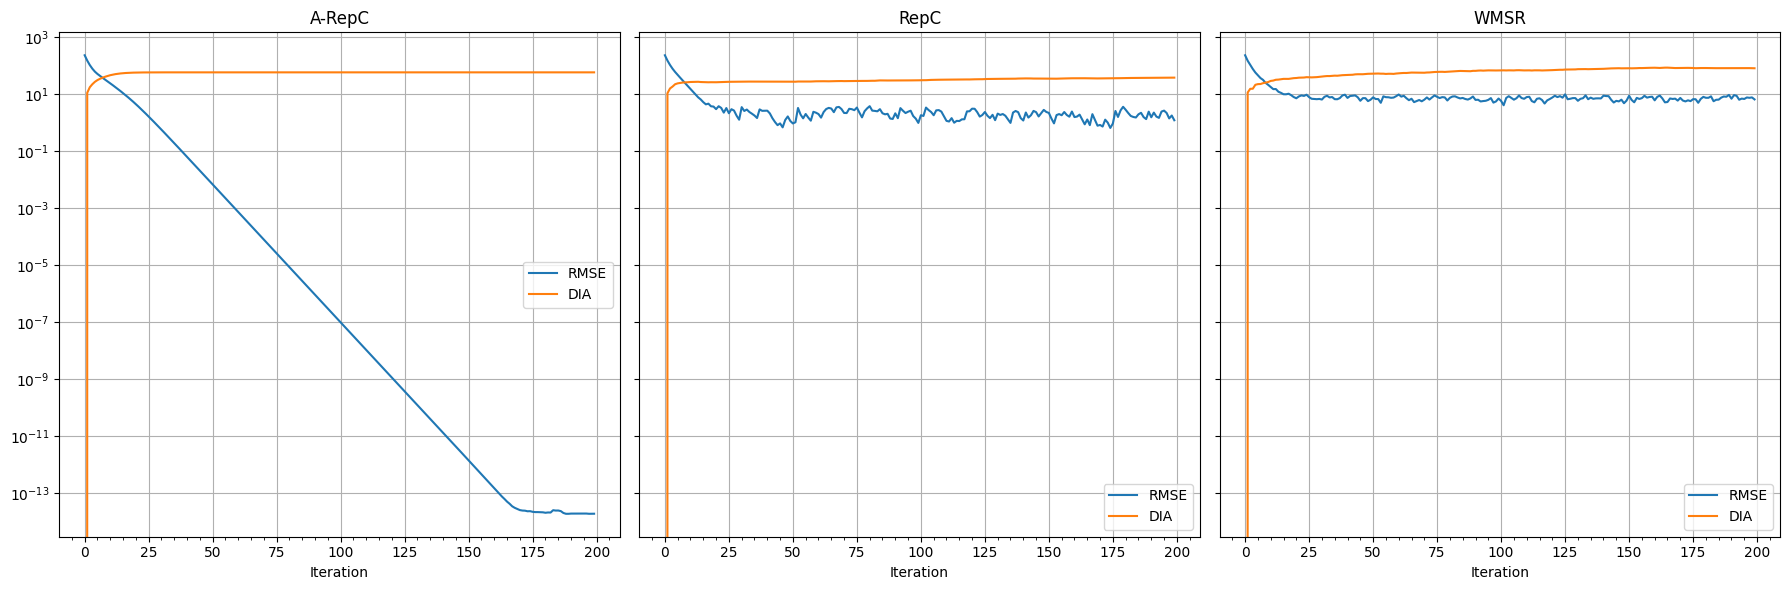

In [101]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.axes as maxes

    axes: tp.Sequence[maxes.Axes]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    for ax, method, rmse, drift in zip(
        axes,
        ["A-RepC", "RepC", "WMSR"],
        [aprec_rmse, repc_rmse, wmsr_rmse],
        [aprec_drift, repc_drift, wmsr_drift],
    ):
        ax.semilogy(rmse, label="RMSE")
        ax.semilogy(drift, label="DIA")
        ax.set_title(method)
        ax.set_xlabel("Iteration")
        ax.minorticks_on()
        ax.grid(which="major", linestyle="-", linewidth=0.8)
        ax.grid(which="minor", axis="y", linestyle="--", linewidth=0.5)
        ax.legend()

    fig.tight_layout()
    fig.savefig(FIGURE_PATH / "comparison.pdf", format="pdf")